<a href="https://colab.research.google.com/github/Ankitghodke/agentic_ai/blob/main/recoverypradictiontask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("/content/shaha_finlease_recovery_dataset.csv")
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Stats:\n", df.describe())

Shape: (9000, 12)

Missing Values:
 account_id            0
loan_amount           0
outstanding_amount    0
days_past_due         0
customer_location     0
income_band           0
payment_history       0
contact_attempts      0
last_channel          0
last_outcome          0
assigned_channel      0
recovery_amount       0
dtype: int64

Basic Stats:
         loan_amount  outstanding_amount  days_past_due  contact_attempts  \
count  9.000000e+03        9.000000e+03    9000.000000       9000.000000   
mean   2.505767e+05        1.588952e+05     228.331111          7.081778   
std    3.008146e+05        2.047988e+05     206.036617          4.715672   
min    1.000800e+04        3.152000e+03       1.000000          1.000000   
25%    4.686400e+04        2.688150e+04      86.000000          4.000000   
50%    1.186805e+05        6.735850e+04     161.000000          6.000000   
75%    3.107508e+05        2.001768e+05     303.000000          9.000000   
max    1.199394e+06        1.115862e+06 

In [2]:
df['recovery_rate'] = df['recovery_amount'] / df['outstanding_amount']
df['is_recovered'] = df['recovery_amount'].apply(lambda x: 1 if x > 0 else 0)
df['is_recovered_label'] = df['recovery_amount'].apply(lambda x: 'Yes' if x > 0 else 'No')
df['dpd_bucket'] = pd.cut(df['days_past_due'],
                    bins=[0, 90, 180, 365, 9999],
                    labels=['0-90 days', '91-180 days', '181-365 days', '365+ days'])

print(df[['recovery_rate', 'is_recovered_label', 'dpd_bucket']].head(10))

   recovery_rate is_recovered_label    dpd_bucket
0       0.000000                 No  181-365 days
1       0.819817                Yes   91-180 days
2       0.000000                 No     365+ days
3       0.000000                 No     365+ days
4       0.000000                 No  181-365 days
5       0.000000                 No  181-365 days
6       0.000000                 No     0-90 days
7       0.000000                 No     0-90 days
8       0.742713                Yes     0-90 days
9       0.324306                Yes     0-90 days


In [3]:
overall_recovery = df['recovery_amount'].sum() / df['outstanding_amount'].sum() * 100
zero = (df['recovery_amount'] == 0).sum()
nonzero = (df['recovery_amount'] > 0).sum()

print(f"Overall Portfolio Recovery %: {overall_recovery:.2f}%")
print(f"Accounts with ZERO recovery: {zero} ({zero/9000*100:.1f}%)")
print(f"Accounts with SOME recovery: {nonzero} ({nonzero/9000*100:.1f}%)")

Overall Portfolio Recovery %: 17.73%
Accounts with ZERO recovery: 6130 (68.1%)
Accounts with SOME recovery: 2870 (31.9%)


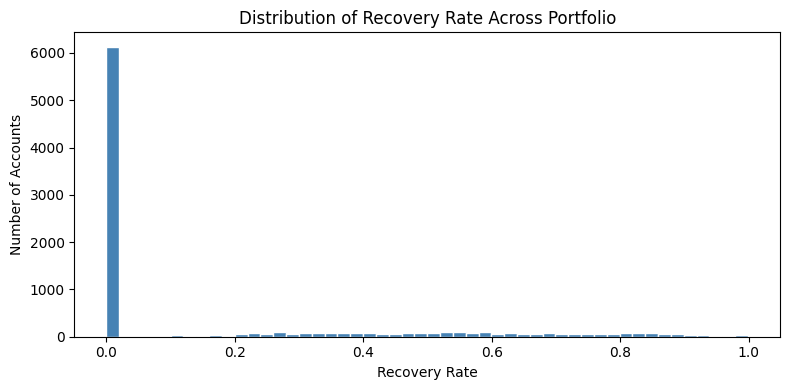

In [4]:
plt.figure(figsize=(8,4))
plt.hist(df['recovery_rate'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Recovery Rate Across Portfolio')
plt.xlabel('Recovery Rate')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.savefig('chart_distribution.png', dpi=150)
plt.show()

In [5]:
categories = ['payment_history', 'last_outcome', 'assigned_channel',
              'customer_location', 'income_band', 'dpd_bucket']

for col in categories:
    result = df.groupby(col)['recovery_rate'].mean().sort_values(ascending=False)
    print(f"\nRecovery Rate by {col}:")
    print(result.round(4))
    print("-" * 40)


Recovery Rate by payment_history:
payment_history
Good       0.3962
Average    0.1942
Poor       0.0456
Name: recovery_rate, dtype: float64
----------------------------------------

Recovery Rate by last_outcome:
last_outcome
Paid           0.3658
Promised       0.2574
No Response    0.1256
Refused        0.0597
Name: recovery_rate, dtype: float64
----------------------------------------

Recovery Rate by assigned_channel:
assigned_channel
Field    0.2287
Call     0.1577
Legal    0.0717
Name: recovery_rate, dtype: float64
----------------------------------------

Recovery Rate by customer_location:
customer_location
Tier 3    0.1830
Tier 2    0.1765
Tier 1    0.1611
Name: recovery_rate, dtype: float64
----------------------------------------

Recovery Rate by income_band:
income_band
High      0.2132
Medium    0.1799
Low       0.1516
Name: recovery_rate, dtype: float64
----------------------------------------

Recovery Rate by dpd_bucket:
dpd_bucket
0-90 days       0.2286
91-180 days 

/tmp/ipykernel_13782/3752317992.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby(col)['recovery_rate'].mean().sort_values(ascending=False)


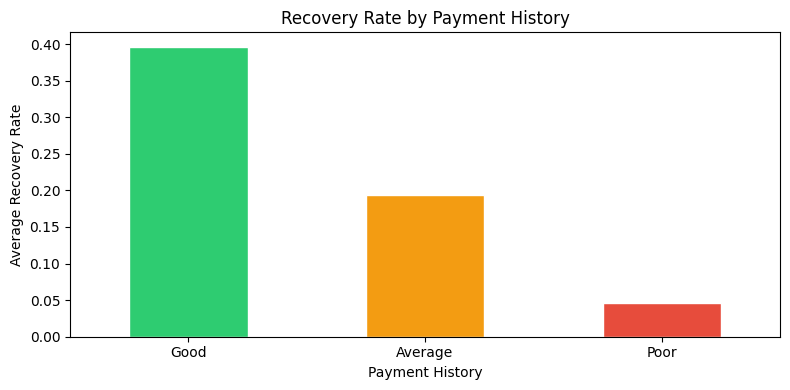

In [6]:
plt.figure(figsize=(8,4))
df.groupby('payment_history')['recovery_rate'].mean().reindex(
    ['Good', 'Average', 'Poor']).plot(
    kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white')
plt.title('Recovery Rate by Payment History')
plt.ylabel('Average Recovery Rate')
plt.xlabel('Payment History')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_payment_history.png', dpi=150)
plt.show()

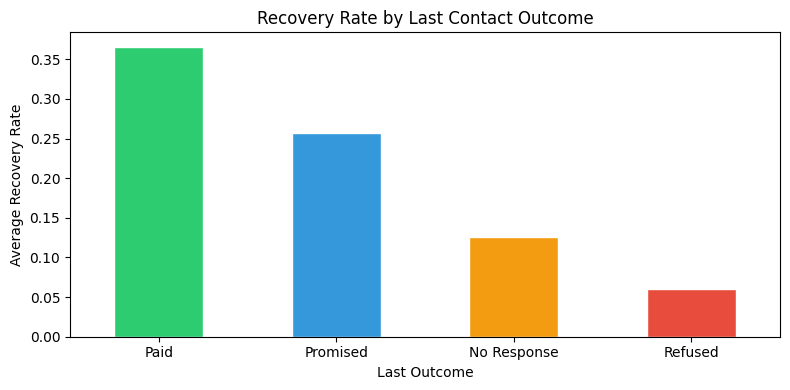

In [7]:
plt.figure(figsize=(8,4))
df.groupby('last_outcome')['recovery_rate'].mean().sort_values(
    ascending=False).plot(
    kind='bar', color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
    edgecolor='white')
plt.title('Recovery Rate by Last Contact Outcome')
plt.ylabel('Average Recovery Rate')
plt.xlabel('Last Outcome')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart2_last_outcome.png', dpi=150)
plt.show()

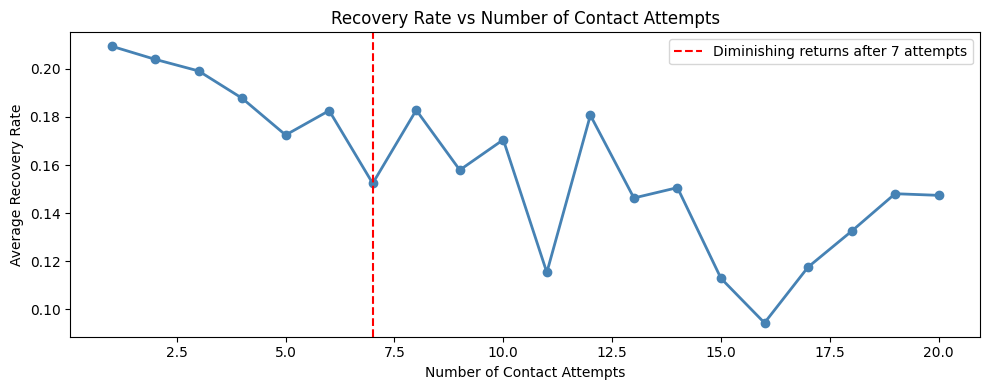

In [8]:
contact_recovery = df.groupby('contact_attempts')['recovery_rate'].mean()

plt.figure(figsize=(10,4))
plt.plot(contact_recovery.index, contact_recovery.values,
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=7, color='red', linestyle='--', label='Diminishing returns after 7 attempts')
plt.title('Recovery Rate vs Number of Contact Attempts')
plt.xlabel('Number of Contact Attempts')
plt.ylabel('Average Recovery Rate')
plt.legend()
plt.tight_layout()
plt.savefig('chart3_contact_attempts.png', dpi=150)
plt.show()

In [9]:
df_corr = pd.get_dummies(df[['payment_history', 'income_band',
                              'customer_location', 'last_outcome']])
df_corr['days_past_due'] = df['days_past_due']
df_corr['outstanding_amount'] = df['outstanding_amount']
df_corr['contact_attempts'] = df['contact_attempts']
df_corr['recovery_rate'] = df['recovery_rate']

correlation = df_corr.corr()['recovery_rate'].sort_values(ascending=False)
print("Variables most correlated with Recovery Rate:")
print(correlation.round(4))

Variables most correlated with Recovery Rate:
recovery_rate               1.0000
payment_history_Good        0.3605
last_outcome_Paid           0.2460
last_outcome_Promised       0.1750
income_band_High            0.0674
payment_history_Average     0.0635
customer_location_Tier 3    0.0203
income_band_Medium          0.0155
outstanding_amount          0.0085
customer_location_Tier 2    0.0069
customer_location_Tier 1   -0.0285
income_band_Low            -0.0691
contact_attempts           -0.0755
last_outcome_No Response   -0.1395
days_past_due              -0.1542
last_outcome_Refused       -0.2130
payment_history_Poor       -0.3491
Name: recovery_rate, dtype: float64


In [10]:
def calculate_score(row):
    score = 0
    if row['payment_history'] == 'Good':
        score += 2
    elif row['payment_history'] == 'Average':
        score += 1
    if row['last_outcome'] in ['Paid', 'Promised']:
        score += 2
    if row['income_band'] == 'High':
        score += 1
    if row['days_past_due'] < 180:
        score += 1
    return score

df['recovery_score'] = df.apply(calculate_score, axis=1)
df['segment'] = pd.cut(df['recovery_score'],
                bins=[-1, 0, 2, 4, 6],
                labels=['Write-Off', 'Low Potential',
                        'Moderate Potential', 'High Potential'])

segment_summary = df.groupby('segment').agg(
    total_accounts=('account_id', 'count'),
    total_outstanding=('outstanding_amount', 'sum'),
    avg_recovery_rate=('recovery_rate', 'mean'),
    total_recovered=('recovery_amount', 'sum')
).reset_index()

segment_summary['avg_recovery_rate'] = (segment_summary['avg_recovery_rate'] * 100).round(1)
segment_summary['total_outstanding'] = segment_summary['total_outstanding'].apply(lambda x: f"₹{x:,.0f}")
segment_summary['total_recovered'] = segment_summary['total_recovered'].apply(lambda x: f"₹{x:,.0f}")
print(segment_summary)

              segment  total_accounts total_outstanding  avg_recovery_rate  \
0           Write-Off             930      ₹144,418,506                2.7   
1       Low Potential            4238      ₹662,961,554                9.5   
2  Moderate Potential            3034      ₹493,752,067               23.5   
3      High Potential             798      ₹128,924,987               53.9   

  total_recovered  
0      ₹4,122,577  
1     ₹64,681,731  
2    ₹117,168,725  
3     ₹67,642,798  


/tmp/ipykernel_13782/2472105881.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = df.groupby('segment').agg(


In [11]:
# Legal wasted on small accounts
legal_low = df[(df['assigned_channel'] == 'Legal') & (df['outstanding_amount'] < 10000)]
print(f"Accounts wrongly assigned Legal (outstanding < ₹10,000): {len(legal_low)}")
print(f"Total outstanding in these accounts: ₹{legal_low['outstanding_amount'].sum():,}")

print()

# Call assigned to high potential high value accounts
call_high = df[(df['assigned_channel'] == 'Call') &
               (df['payment_history'] == 'Good') &
               (df['outstanding_amount'] > 50000)]
print(f"High potential accounts stuck on Call Center: {len(call_high)}")
print(f"Total outstanding being underserved: ₹{call_high['outstanding_amount'].sum():,}")

Accounts wrongly assigned Legal (outstanding < ₹10,000): 73
Total outstanding in these accounts: ₹532,778

High potential accounts stuck on Call Center: 303
Total outstanding being underserved: ₹78,840,171


In [12]:
df_model = df.copy()
cat_cols = ['payment_history', 'income_band', 'customer_location',
            'last_outcome', 'assigned_channel', 'last_channel']

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

features = ['days_past_due', 'outstanding_amount', 'contact_attempts',
            'payment_history', 'income_band', 'customer_location',
            'last_outcome', 'loan_amount']

X = df_model[features]
y = df_model['is_recovered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:,1]
auc = roc_auc_score(y_test, y_pred_proba)
print(f"Model AUC Score: {auc:.4f}")
print("(Above 0.70 is good. Above 0.75 is very good)")

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop Features that predict recovery:")
print(importance.round(4))

# Add probability score to each account
df['recovery_probability'] = model.predict_proba(df_model[features])[:,1]
print("\nTop 10 accounts most likely to recover:")
print(df[['account_id', 'outstanding_amount', 'recovery_probability',
          'segment']].sort_values('recovery_probability', ascending=False).head(10))

Model AUC Score: 0.7427
(Above 0.70 is good. Above 0.75 is very good)

Top Features that predict recovery:
              feature  importance
0       days_past_due      0.2238
7         loan_amount      0.1931
1  outstanding_amount      0.1902
3     payment_history      0.1188
2    contact_attempts      0.1131
6        last_outcome      0.0805
5   customer_location      0.0428
4         income_band      0.0377

Top 10 accounts most likely to recover:
     account_id  outstanding_amount  recovery_probability             segment
6808  SFL106808              107829                  1.00      High Potential
1217  SFL101217               52279                  1.00      High Potential
6222  SFL106222              363250                  1.00      High Potential
3162  SFL103162              118896                  1.00      High Potential
4629  SFL104629               49641                  0.99      High Potential
2739  SFL102739               44355                  0.99      High Potential
